# t-SNE

In [153]:
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.manifold import TSNE

## Carregar dados

In [154]:
df_cosmeticos = pd.read_csv("./dataset/cosmeticos.csv")
df_cosmeticos.info()

<class 'pandas.DataFrame'>
RangeIndex: 1472 entries, 0 to 1471
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Tipo           1472 non-null   str    
 1   Marca          1472 non-null   str    
 2   Nome           1472 non-null   str    
 3   Preco          1472 non-null   int64  
 4   Rating         1472 non-null   float64
 5   Ingredientes   1472 non-null   str    
 6   Pele_Mista     1472 non-null   int64  
 7   Pele_Seca      1472 non-null   int64  
 8   Pele_Normal    1472 non-null   int64  
 9   Pele_Oleosa    1472 non-null   int64  
 10  Pele_Sensivel  1472 non-null   int64  
dtypes: float64(1), int64(6), str(4)
memory usage: 126.6 KB


In [155]:
df_cosmeticos.head(10)

,Tipo,Marca,Nome,Preco,Rating,Ingredientes,Pele_Mista,Pele_Seca,Pele_Normal,Pele_Oleosa,Pele_Sensivel
0,Moisturizer,LA MER,Crème de la Mer,175,4.1,"Algae (Seaweed) Extract, Mineral Oil, Petrolat...",1,1,1,1,1
1,Moisturizer,SK-II,Facial Treatment Essence,179,4.1,"Galactomyces Ferment Filtrate (Pitera), Butyle...",1,1,1,1,1
2,Moisturizer,DRUNK ELEPHANT,Protini™ Polypeptide Cream,68,4.4,"Water, Dicaprylyl Carbonate, Glycerin, Ceteary...",1,1,1,1,0
3,Moisturizer,LA MER,The Moisturizing Soft Cream,175,3.8,"Algae (Seaweed) Extract, Cyclopentasiloxane, P...",1,1,1,1,1
4,Moisturizer,IT COSMETICS,Your Skin But Better™ CC+™ Cream with SPF 50+,38,4.1,"Water, Snail Secretion Filtrate, Phenyl Trimet...",1,1,1,1,1
5,Moisturizer,TATCHA,The Water Cream,68,4.2,"Water, Saccharomyces/Camellia Sinensis Leaf/Cl...",1,0,1,1,1
6,Moisturizer,DRUNK ELEPHANT,Lala Retro™ Whipped Cream,60,4.2,"Water, Glycerin, Caprylic/ Capric Triglyceride...",1,1,1,1,0
7,Moisturizer,DRUNK ELEPHANT,Virgin Marula Luxury Facial Oil,72,4.4,100% Unrefined Sclerocraya Birrea (Marula) Ker...,1,1,1,1,0
8,Moisturizer,KIEHL'S SINCE 1851,Ultra Facial Cream,29,4.4,"Water, Glycerin, Cyclohexasiloxane, Squalane, ...",1,1,1,1,1
9,Moisturizer,LA MER,Little Miss Miracle Limited-Edition Crème de l...,325,5.0,"Algae (Seaweed) Extract, Mineral Oil, Petrolat...",0,0,0,0,0


## EDA
Transformar valores da coluna "Ingredientes" em um novo Dataframe

In [156]:
df_cosmeticos_eda = df_cosmeticos.copy()
df_cosmeticos_eda = df_cosmeticos_eda['Ingredientes'].str.split(',')
df_cosmeticos_eda.head(10)

0    [Algae (Seaweed) Extract,  Mineral Oil,  Petro...
1    [Galactomyces Ferment Filtrate (Pitera),  Buty...
2    [Water,  Dicaprylyl Carbonate,  Glycerin,  Cet...
3    [Algae (Seaweed) Extract,  Cyclopentasiloxane,...
4    [Water,  Snail Secretion Filtrate,  Phenyl Tri...
5    [Water,  Saccharomyces/Camellia Sinensis Leaf/...
6    [Water,  Glycerin,  Caprylic/ Capric Triglycer...
7    [100% Unrefined Sclerocraya Birrea (Marula) Ke...
8    [Water,  Glycerin,  Cyclohexasiloxane,  Squala...
9    [Algae (Seaweed) Extract,  Mineral Oil,  Petro...
Name: Ingredientes, dtype: object

In [157]:
df_ingredientes = df_cosmeticos_eda.explode('Ingredientes')
df_ingredientes

0              Algae (Seaweed) Extract
1                          Mineral Oil
2                           Petrolatum
3                             Glycerin
4                        Isohexadecane
                     ...              
45811           Alpha-isomethyl Ionone
45812                 CI 14700 (Red 4)
45813              CI 19140 (Yellow 5)
45814               CI 42090 (Blue 1).
45815    Visit the DERMAFLASH boutique
Name: Ingredientes, Length: 45816, dtype: str

In [158]:
df_cosmeticos.describe()

,Preco,Rating,Pele_Mista,Pele_Seca,Pele_Normal,Pele_Oleosa,Pele_Sensivel
count,1472.000000,1472.000000,1472.00000,1472.000000,1472.000000,1472.000000,1472.000000
mean,55.584239,4.153261,0.65625,0.614130,0.652174,0.607337,0.513587
std,45.014429,0.633918,0.47512,0.486965,0.476442,0.488509,0.499985
min,3.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,4.000000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,42.500000,4.300000,1.00000,1.000000,1.000000,1.000000,1.000000
75%,68.000000,4.500000,1.00000,1.000000,1.000000,1.000000,1.000000
max,370.000000,5.000000,1.00000,1.000000,1.000000,1.000000,1.000000


### Distribuição Tipo

/tmp/ipykernel_814015/1492371430.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


Text(0.5, 0, 'Type')

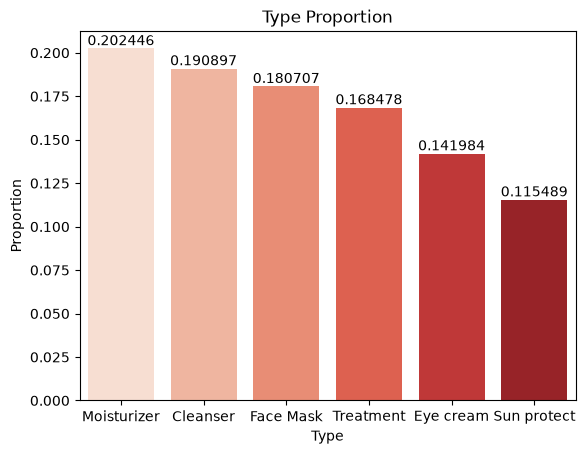

In [159]:
percentual_tipo = df_cosmeticos.value_counts("Tipo", normalize=True) # type: ignore
ax = sns.barplot(
  percentual_tipo, # type: ignore
  palette="Reds",
)
for container in ax.containers:
    ax.bar_label(container=container, label_type='edge') # type: ignore
plt.title("Type Proportion")
plt.ylabel("Proportion")
plt.xlabel("Type")

### Distribuição Marca

/tmp/ipykernel_814015/2874541623.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


Text(0.5, 0, 'Brand')

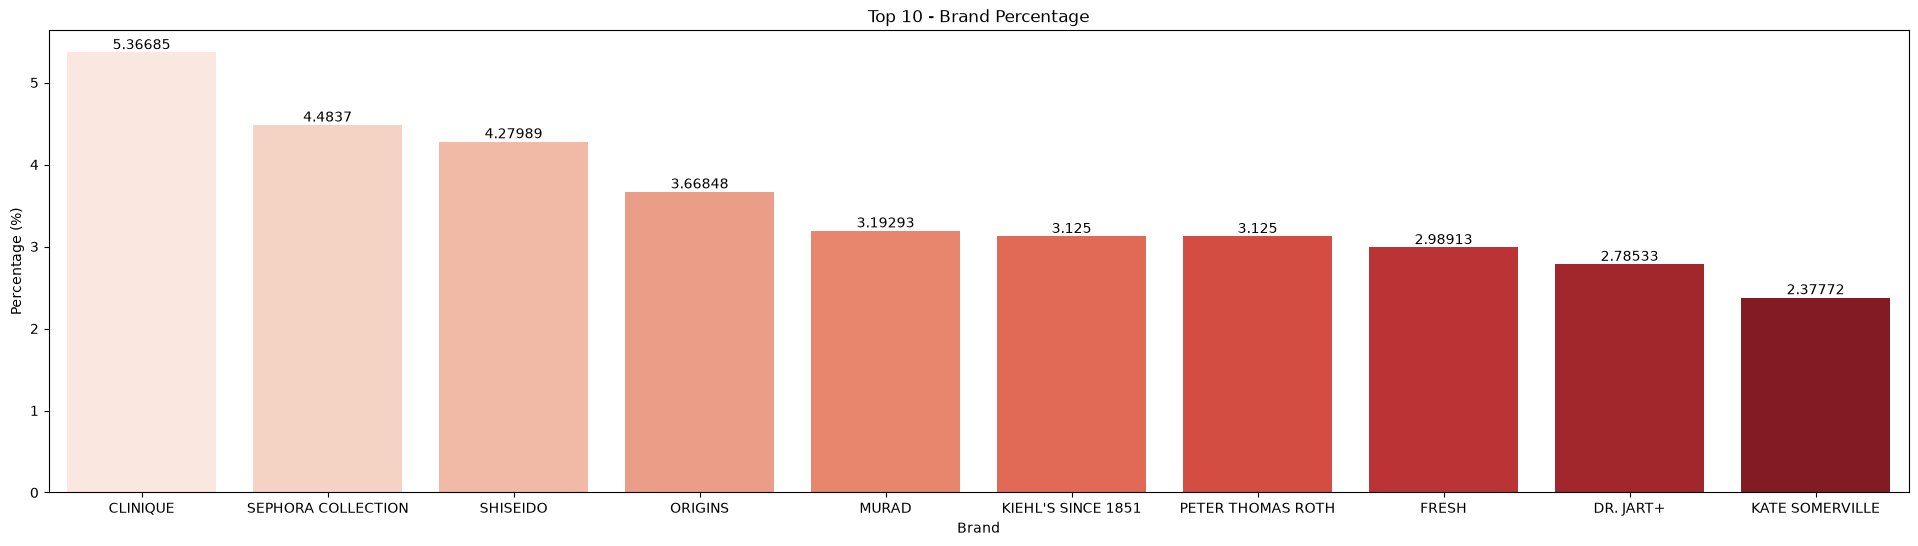

In [160]:
percentual_marca = df_cosmeticos.value_counts("Marca", normalize=True).head(10) * 100 # type: ignore
plt.figure(figsize=(24,6))
ax = sns.barplot(
  percentual_marca, # type: ignore
  palette="Reds",
)
for container in ax.containers:
    ax.bar_label(container=container, label_type='edge') # type: ignore
plt.title("Top 10 - Brand Percentage")
plt.ylabel("Percentage (%)")
plt.xlabel("Brand")

In [161]:
### Quantidade de Marcas
len(df_cosmeticos['Marca'].unique())

116

### Distribuição Ingredientes

/tmp/ipykernel_814015/210472584.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


Text(0.5, 0, 'Ingredient')

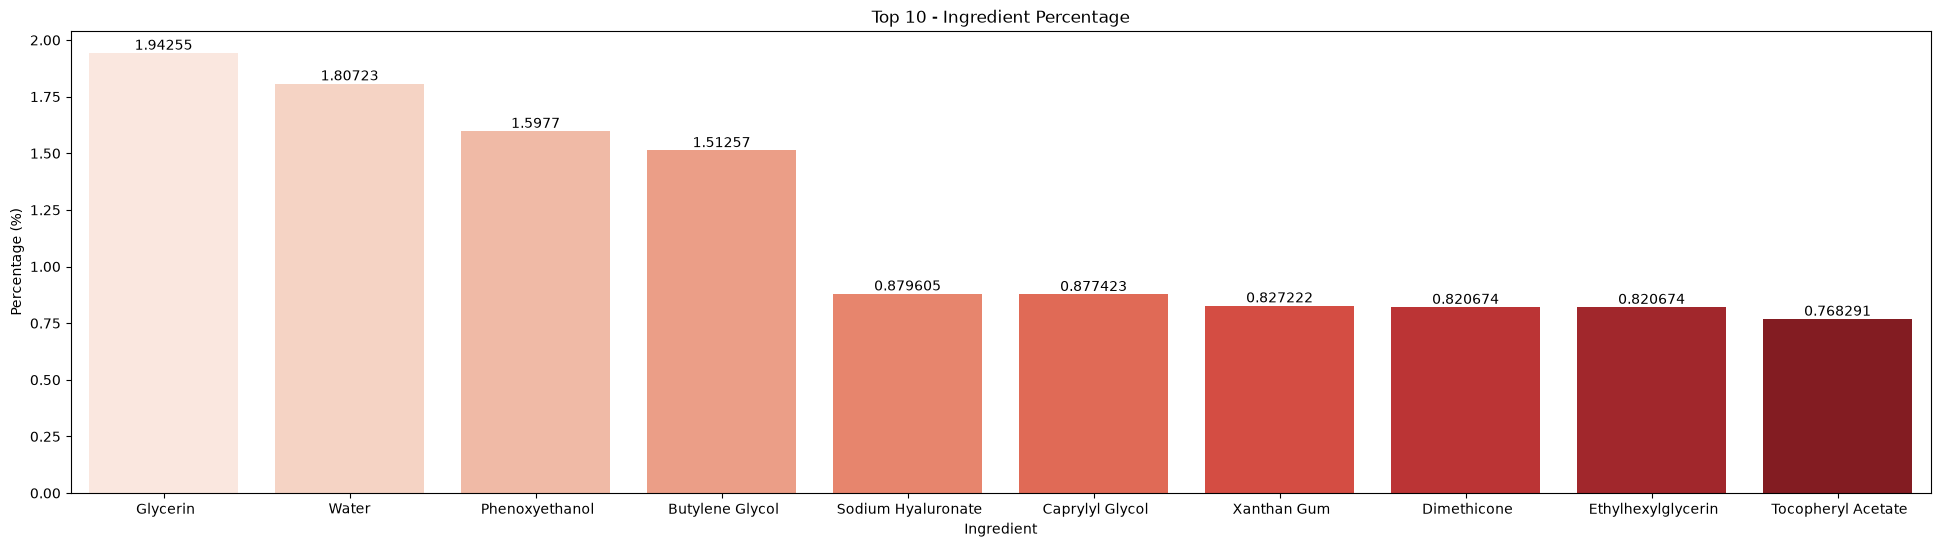

In [162]:
df_ingredientes = pd.DataFrame(df_ingredientes)
percentual_ingrediente = df_ingredientes.value_counts("Ingredientes", normalize=True).head(10) * 100 # type: ignore
plt.figure(figsize=(24,6))
ax = sns.barplot(
  percentual_ingrediente, # type: ignore
  palette="Reds",
)
for container in ax.containers:
    ax.bar_label(container=container, label_type='edge') # type: ignore
plt.title("Top 10 - Ingredient Percentage")
plt.ylabel("Percentage (%)")
plt.xlabel("Ingredient")

In [163]:
# Ingredientes no Dataset
len(df_ingredientes['Ingredientes'].unique())

7298

### Distribuição Preço

Text(0.5, 1.0, 'Price Distribution')

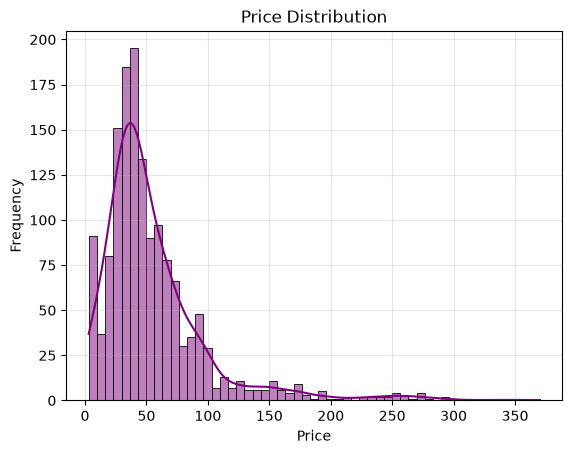

In [164]:
sns.histplot(
  df_cosmeticos,
  x='Preco',
  kde=True,
  color='purple',
)
plt.grid(visible=True, alpha=0.3)
plt.ylabel("Frequency")
plt.xlabel("Price")
plt.title("Price Distribution")

### Distribuição Avaliação

Text(0.5, 1.0, 'Rating Distribution')

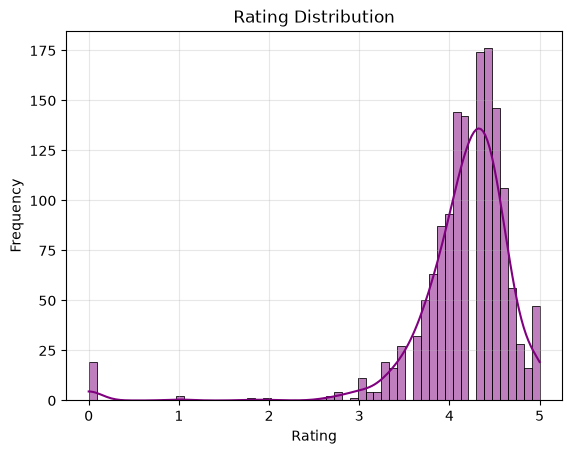

In [165]:
sns.histplot(
  df_cosmeticos,
  x='Rating',
  kde=True,
  color='purple',
)
plt.grid(visible=True, alpha=0.3)
plt.ylabel("Frequency")
plt.xlabel("Rating")
plt.title("Rating Distribution")

## Análise Bivariada

### Tipo x Preço

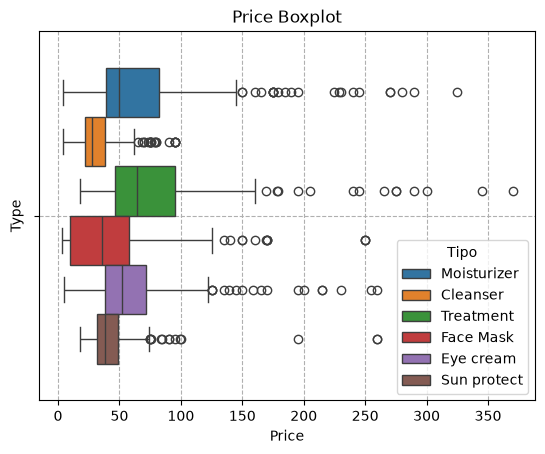

In [166]:
sns.boxplot(
  data=df_cosmeticos,
  x='Preco',
  hue='Tipo',
)
plt.xlabel("Price")
plt.ylabel("Type")
plt.title("Price Boxplot")
plt.grid(visible=True, linestyle='--')

### Tipo x Rating

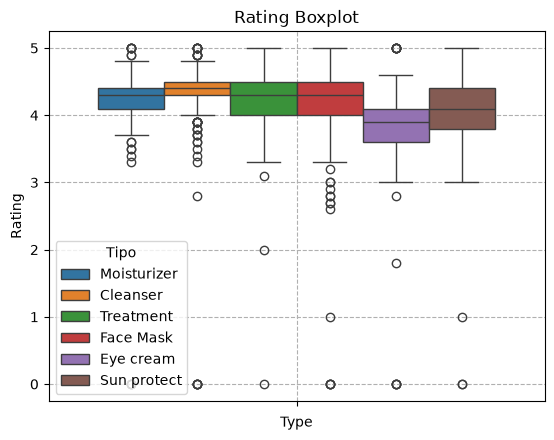

In [167]:
sns.boxplot(
  data=df_cosmeticos,
  y='Rating',
  hue='Tipo',
)
plt.ylabel("Rating")
plt.xlabel("Type")
plt.title("Rating Boxplot")
plt.grid(visible=True, linestyle='--')

### Preço x Rating

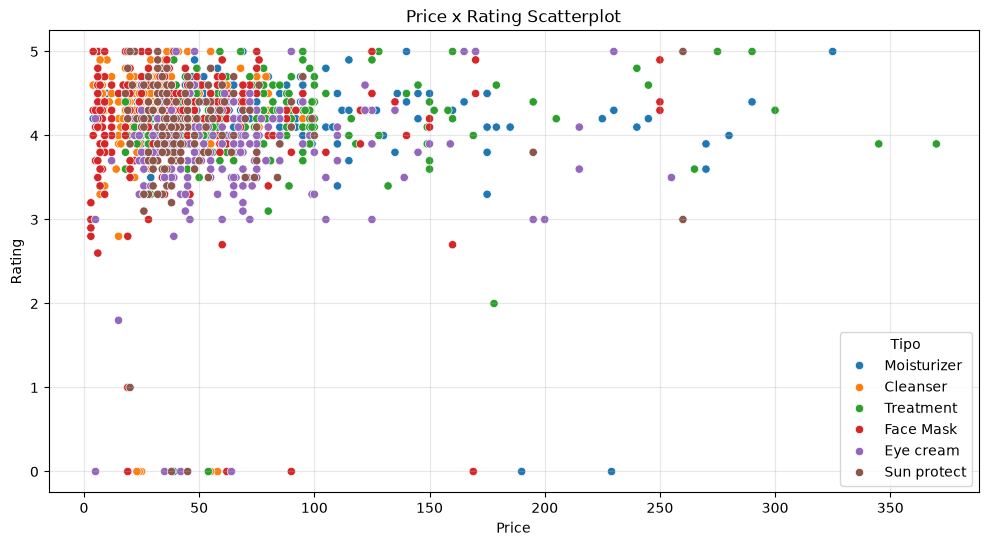

In [168]:
plt.figure(figsize=(12,6))
sns.scatterplot(
  df_cosmeticos,
  x="Preco",
  y='Rating',
  hue='Tipo'
)
plt.title("Price x Rating Scatterplot")
plt.ylabel("Rating")
plt.xlabel("Price")
plt.grid(visible=True, alpha=0.3)

### Correlação de Pearson

Text(0.5, 1.0, 'Pearson Correlation')

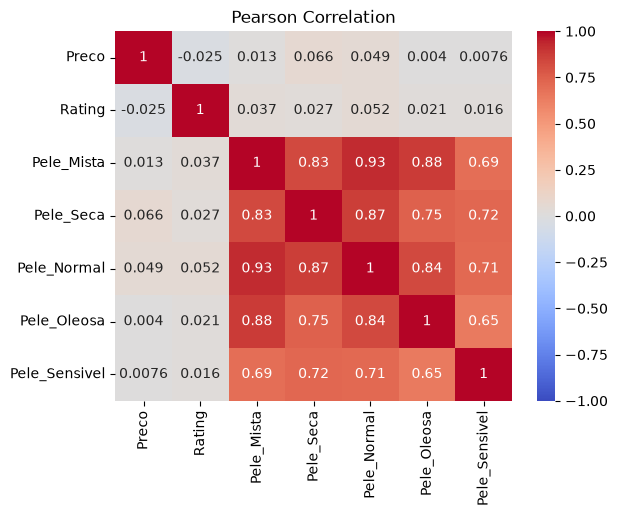

In [169]:
corr_pearson = df_cosmeticos.corr(method='pearson', numeric_only=True)
sns.heatmap(
  corr_pearson,
  vmin=-1,
  vmax=1,
  cmap='coolwarm',
  annot=True
)
plt.title("Pearson Correlation")

## Preparação de Dados

In [170]:
X = df_cosmeticos.copy()
X.drop(columns=['Nome', 'Ingredientes'], inplace=True)

numeric_features = ['Rating', 'Preco']
categorical_features = ['Marca', 'Tipo']

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
  transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
  ],
  remainder='passthrough',
)

X_transformed = preprocessor.fit_transform(X=X)

X_transformed = X_transformed.toarray()


## Treinamento do Modelo

In [ ]:
df_results = pd.DataFrame()

perplexities = list(range(5, 50+1))
for perplexity in perplexities:
    print(f"Perplexity: {perplexity}")
    tsne = TSNE(
      n_components=2,
      perplexity=perplexity,
      init='random',
      random_state=51,
      max_iter=1000,
    )

    tsne_result = tsne.fit_transform(X=X_transformed)

    temp_df = pd.DataFrame(tsne_result, columns=['Component1', 'Component2'])
    temp_df['Perplexity'] = perplexity
    df_results = pd.concat([df_results, temp_df], ignore_index=True)


Perplexity: 5
Perplexity: 6
Perplexity: 7
Perplexity: 8
Perplexity: 9
Perplexity: 10
Perplexity: 11
Perplexity: 12
Perplexity: 13
Perplexity: 14
Perplexity: 15
Perplexity: 16
Perplexity: 17
Perplexity: 18
Perplexity: 19
Perplexity: 20
Perplexity: 21
Perplexity: 22
Perplexity: 23
Perplexity: 24
Perplexity: 25
Perplexity: 26
Perplexity: 27


## Visualizar Resultados

### 2D

In [ ]:
import plotly.io as pio

pio.renderers.default = 'browser'

fig = px.scatter(df_results, x='Component1', y='Component2', animation_frame='Perplexity', title="Visualização do t-SNE com variação do Perplexity")
fig.show()